# 03. PyTorch Computer Vision

This notebook builds an image classification workflow on the Fashion MNIST dataset using PyTorch and TorchVision — covering data loading, a baseline linear model, and a full training/evaluation loop.

- `torchvision.datasets` — provides ready-to-use vision datasets with built-in train/test splits
- `torch.utils.data.DataLoader` — batches and shuffles data for training
- `nn.Sequential` — chains layers into a simple feed-forward model

**Note:** This notebook trains on CPU by default; a CUDA/ROCm device is only used if detected in the setup cell.

**Resources**
1. Notebook: https://www.learnpytorch.io/03_pytorch_computer_vision/
2. Video: https://www.youtube.com/watch?v=V_xro1bcAuA&t=5277s

## Setup & Environment Check

Import the core libraries and detect the available device up front so every tensor and model can be moved to the right place later in the notebook.

- `torch.cuda.is_available()` — checks for a CUDA/ROCm-capable GPU and falls back to CPU otherwise
- `warnings.filterwarnings("ignore")` — suppresses noisy library warnings so the output stays readable
- `DEVICE` — global variable set here and reused throughout the notebook for `.to(DEVICE)` calls

**Note:** This model is trained entirely on `"cpu"` later in the notebook — `DEVICE` is detected here for reference and timing comparisons, not used to move the model or data.

In [1]:
# Capture runtime details so later cells can choose the right device.
import platform
import torch
from torch import nn
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torchvision
from torchvision  import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

# Keep notebook output focused on the example results.
warnings.filterwarnings("ignore")

print(f"--- System Information ---")
print(f"Platform: {platform.platform()}")
print(f"Python:   {platform.python_version()}")
print(f"PyTorch:  {torch.__version__}")

print(f"\n--- GPU/ROCm Accelerators ---")
cuda_available = torch.cuda.is_available()
print(f"CUDA Available: {cuda_available}")

if cuda_available:
    print(f"Device Count:   {torch.cuda.device_count()}")
    print(f"Primary Device: {torch.cuda.get_device_name(0)}")
    DEVICE = torch.device("cuda:0")
else:
    print("Optimization Note: No CUDA-capable GPU detected. Training and inference will use the CPU.")
    DEVICE = torch.device("cpu")


--- System Information ---
Platform: Windows-11-10.0.26200-SP0
Python:   3.12.13
PyTorch:  2.9.1+rocm7.2.1

--- GPU/ROCm Accelerators ---
CUDA Available: True
Device Count:   1
Primary Device: AMD Radeon RX 7900 XT


## Getting the Dataset (TorchVision)

Download the Fashion MNIST dataset via `torchvision.datasets` — a set of 28x28 grayscale images across 10 clothing categories, already split into train and test sets.

- `datasets.FashionMNIST(root=..., train=True/False, download=True, transform=...)` — downloads (if not cached) and loads the dataset
- `transform=transforms.ToTensor()` — converts each PIL image to a `torch.Tensor` and scales pixel values to `[0, 1]`
- `target_transform` — optional transform applied to labels; left as `None` here since labels are already integers

**Note:** Both `train_data` and `test_data` are downloaded to a local `data/` folder — subsequent runs skip the download if the folder already exists.

In [2]:
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transforms.ToTensor(),
    target_transform=None
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transforms.ToTensor(),
    target_transform=None
)

len(train_data), len(test_data)

(60000, 10000)

In [3]:
image = train_data[0][0]
print(image.shape, image.min(), image.max())
print(f"Label: {train_data[0][1]}, Class Name: {train_data.classes[train_data[0][1]]}")

torch.Size([1, 28, 28]) tensor(0.) tensor(1.)
Label: 9, Class Name: Ankle boot


In [4]:
image, label = train_data[0]
print(f"Image shape: {image.shape}, Label: {label}, Class Name: {train_data.classes[label]}")
image

Image shape: torch.Size([1, 28, 28]), Label: 9, Class Name: Ankle boot


tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
          0.2863, 0.0000, 0.0000, 0.0039, 0.0157, 0.0000,

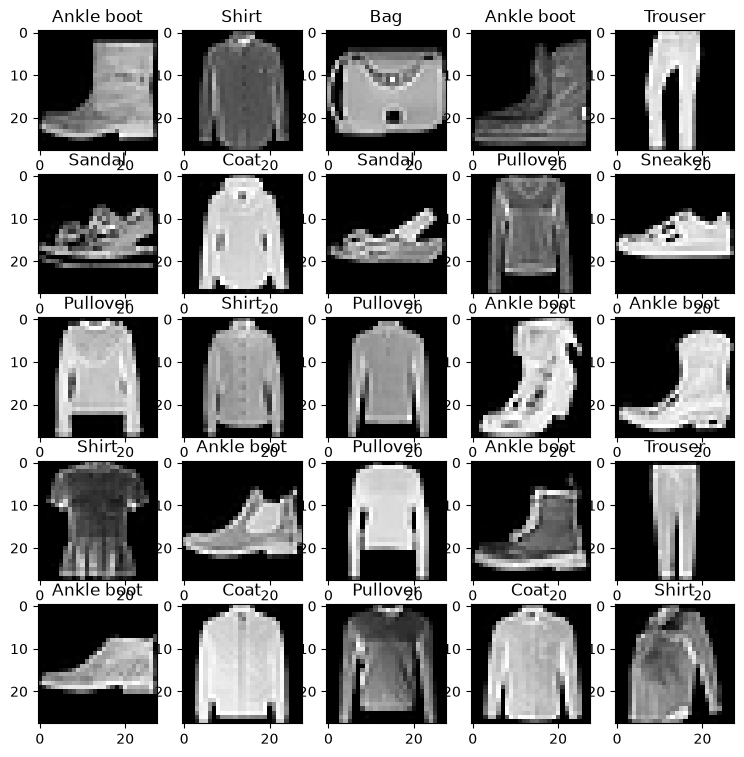

In [5]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 5, 5
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(train_data.classes[label])

## Prepare DataLoader

Wrap the datasets in `DataLoader` objects so training happens in mini-batches instead of one image at a time.

- `DataLoader(dataset=..., batch_size=32, shuffle=True/False)` — turns a `Dataset` into an iterable of batches
- `shuffle=True` (train) — reshuffles data each epoch to reduce overfitting and improve generalization
- `shuffle=False` (test) — order doesn't matter for evaluation, so shuffling is skipped
- `BATCH_SIZE = 32` — a common default; smaller batches update weights more often at the cost of noisier gradients

**Note:** `next(iter(train_dataloader))` pulls a single batch out for inspection — it does not advance the DataLoader for the actual training loop later, since a fresh iterator is created each epoch.

In [6]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32

# Turn the training and test datasets into DataLoaders (From PyTorch Dataset to Python iterable)
# Using Mini-batches to speed up training and reduce memory usage and to improve generalization (more chances to escape local minima/update weights more often): batch size = 32 (default)

train_dataloader = torch.utils.data.DataLoader(dataset=train_data, batch_size=32, shuffle=True) # Shuffle the training data to improve generalization and avoid overfitting (more chances to escape local minima/update weights more often)
test_dataloader = torch.utils.data.DataLoader(dataset=test_data, batch_size=32, shuffle=False) # No need to shuffle the test data as we are not training on it, just evaluating the model's performance on unseen data (easier).

print(f"Data: {train_data}\n\nTest data: {test_data}")
print(f"DataLoaders: {train_dataloader}\n\nTest DataLoader: {test_dataloader}\n\nBatch size: {BATCH_SIZE}\n")

# Check the first batch of training data
print(f"Length of training dataloader: {len(train_dataloader)} of {len(train_dataloader.dataset)} samples")
print(f"Length of test dataloader: {len(test_dataloader)} of {len(test_dataloader.dataset)} samples")

train_features_batch, train_labels_batch = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features_batch.size()}")
print(f"Labels batch shape: {train_labels_batch.size()}")

Data: Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

Test data: Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()
DataLoaders: <torch.utils.data.dataloader.DataLoader object at 0x00000278B09004D0>

Test DataLoader: <torch.utils.data.dataloader.DataLoader object at 0x00000278B0912A20>

Batch size: 32

Length of training dataloader: 1875 of 60000 samples
Length of test dataloader: 313 of 10000 samples
Feature batch shape: torch.Size([32, 1, 28, 28])
Labels batch shape: torch.Size([32])


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

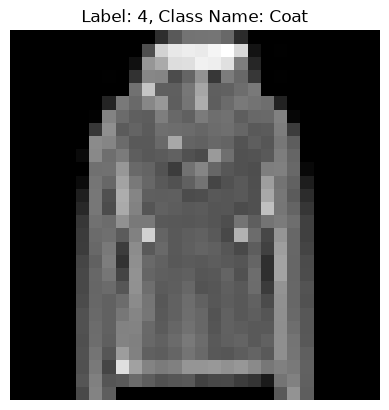

In [7]:
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(f"Label: {label}, Class Name: {train_data.classes[label]}")
plt.axis(False)

## Baseline model

Build the simplest possible classifier: flatten each image into a 1D vector and pass it through two linear layers.

- `nn.Flatten()` — collapses the `[channels, height, width]` image into a single `[batch_size, h*w*c]` vector
- `FashionMNISTModelV0` — a plain `nn.Sequential` stack with no activation functions between layers (a linear baseline)
- `input_shape=28*28` — matches the flattened pixel count of each Fashion MNIST image
- `model_0.state_dict()` — inspects the model's learnable parameters (weights and biases) before any training

**Note:** With no non-linear activations, this model can only learn linear decision boundaries — it's meant as a baseline to compare against more capable architectures later.

In [8]:
# Flatten layer
flatten_model = nn.Flatten()

# Get a single sample from the training batch
x = train_features_batch[0]

 # Forward pass through the flatten layer
x_flatten = flatten_model(x)

# Print the shape of the input and output tensors
print(f"Shape before flattening: {x.shape} --> [channels, height, width] where c=channels, h=height, w=width")
print(f"Shape after flattening: {x_flatten.shape} --> [batch_size, h*w*c] where h=height, w=width, c=channels")

Shape before flattening: torch.Size([1, 28, 28]) --> [channels, height, width] where c=channels, h=height, w=width
Shape after flattening: torch.Size([1, 784]) --> [batch_size, h*w*c] where h=height, w=width, c=channels


In [9]:
class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        # Sequential means that the layers will be executed in the order they are defined
        self.layer_stack = nn.Sequential( 
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )

    def forward(self, x):
        return self.layer_stack(x)

In [10]:
# Set random seed for reproducibility
torch.manual_seed(42)

# Create an instance of the model
model_0 = FashionMNISTModelV0(
    input_shape=28*28,  # Flattened image size (28x28 pixels = 784 from above)
    hidden_units=10,    # Number of hidden units (arbitrary choice, can be tuned)
    output_shape=len(train_data.classes)).to("cpu")

model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [11]:
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
                      [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
                      [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]])),
             ('layer_stack.1.bias',
              tensor([-0.0093,  0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,
                       0.0018,  0.0163])),
             ('layer_stack.2.weight',
              tensor([[ 0.0614, -0.0687,  0.0021,  0.2718,  0.2109,  0.1079, -0.2279, -0.1063,
                        0.2019,  0.2847],
                      [-0.1495,  0.1344, -0.0740,  0.2006, -0.0475, -0.2514, -0.

In [12]:
dummy_x = torch.rand(size=(1, 1, 28, 28)) # Random tensor with shape [batch_size, channels, height, width]
model_0(dummy_x)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

## Loss function and Optimizer (CrossEntropyLoss, SGD)

Define how the model measures error and how it updates its weights to reduce that error.

- `nn.CrossEntropyLoss()` — standard loss for multi-class classification; internally applies `softmax` so no activation is needed on the model's final layer
- `torch.optim.SGD(params=..., lr=0.1)` — Stochastic Gradient Descent optimizer; updates weights in the direction that reduces loss
- `accuracy_fn` — a helper (imported from `helper_functions.py`) that computes classification accuracy from predicted vs. true labels

**Note:** A learning rate of `0.1` is relatively high — appropriate here for a fast-converging baseline, but worth lowering if training becomes unstable on more complex models.

In [13]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1) # Stochastic Gradient Descent (SGD) optimizer with learning rate of 0.1


## Training Loop (Per Batch)

Run the standard PyTorch training loop: forward pass, loss calculation, backward pass, and weight update, repeated per batch and per epoch.

- `model.train()` / `model.eval()` — toggles layers like dropout/batchnorm between training and inference behavior
- `optimizer.zero_grad()` — clears gradients from the previous step before backpropagation
- `loss.backward()` — computes gradients via backpropagation
- `optimizer.step()` — applies the computed gradients to update model weights
- `torch.inference_mode()` — disables gradient tracking during evaluation for faster, memory-efficient inference

**Note:** Train and test accuracy/loss are accumulated per batch and divided by `len(dataloader)` at the end of each epoch to get the average — not divided by the number of samples.

In [14]:
from timeit import default_timer as timer

def print_train_time(start: float, end: float, device: torch.device = None):
    """Print training time."""
    total_time = end - start
    print(f"\nTrain time on {device}: {total_time:.3f} seconds")
    return total_time

In [15]:
start_time = timer()

end_time = timer()
print_train_time(start=start_time, end=end_time, device=DEVICE)


Train time on cuda:0: 0.000 seconds


1.5900004655122757e-05

In [16]:
from tqdm.auto import tqdm

torch.manual_seed(42)
training_time_start_on_cpu = timer()

# Set the number of epochs for training
EPOCHS = 3

# Create a training and testing loop
for epoch in tqdm(range(EPOCHS)):
    print(f"Epoch: {epoch+1}\n---------")

    train_loss, train_acc = 0, 0
    model_0.train()  # Set the model to training mode

    for batch, (X, y) in enumerate(train_dataloader):

        # Forward pass
        y_pred = model_0(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        # Backward pass
        optimizer.zero_grad()  # Zero the gradients before backward pass
        loss.backward()        # Backpropagation
        optimizer.step()       # Update the weights

        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples.")

    # Calculate average loss and accuracy for the epoch
    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)

    test_loss, test_acc = 0, 0
    model_0.eval()  # Set the model to evaluation mode
    with torch.inference_mode():  # Disable gradient calculation for inference
        for X_test, y_test in test_dataloader:
            test_pred = model_0(X_test) # Forward pass
            test_loss += loss_fn(test_pred, y_test).item() # Calculate loss
            test_acc += accuracy_fn(y_true=y_test, y_pred=test_pred.argmax(dim=1)) # Calculate accuracy

    # Calculate average loss and accuracy for the epoch
    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)

    # Calculate training time for the epoch
    epoch_time_end = timer()
    epoch_time = epoch_time_end - training_time_start_on_cpu

    print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}")
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")
    print(f"Epoch Time: {epoch_time:.3f} seconds\n")

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 1
---------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.


 33%|███▎      | 1/3 [00:04<00:08,  4.09s/it]

Train Loss: 0.5904, Train Accuracy: 79.1717
Test Loss: 0.5095, Test Accuracy: 82.0387
Epoch Time: 4.097 seconds

Epoch: 2
---------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.


 67%|██████▋   | 2/3 [00:08<00:04,  4.18s/it]

Train Loss: 0.4763, Train Accuracy: 83.3200
Test Loss: 0.4799, Test Accuracy: 83.1969
Epoch Time: 8.343 seconds

Epoch: 3
---------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.


100%|██████████| 3/3 [00:12<00:00,  4.13s/it]

Train Loss: 0.4550, Train Accuracy: 84.0517
Test Loss: 0.4766, Test Accuracy: 83.4265
Epoch Time: 12.378 seconds



## Make prediction

Wrap the evaluation logic into a reusable `evaluate_model()` function that scores a trained model on any given DataLoader.

- `evaluate_model(model, data_loader, loss_fn, accuracy_fn, device)` — runs a full evaluation pass and returns average loss and accuracy
- `X.to(device), y.to(device)` — moves each batch to the target device before the forward pass
- Returns a `(loss, acc)` tuple rather than printing — keeps the function reusable for comparing multiple models later

**Note:** `device="cpu"` is the default here to match how `model_0` was trained; pass a different device explicitly if evaluating a model trained on GPU.

In [17]:
def evaluate_model(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, accuracy_fn, device: torch.device = "cpu"):
    """Evaluate a PyTorch model on a given dataset."""
    model.eval()  # Set the model to evaluation mode
    loss, acc = 0, 0

    with torch.inference_mode():  # Disable gradient calculation for inference
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)  # Move data to the specified device
            y_pred = model(X)  # Forward pass
            loss += loss_fn(y_pred, y).item()  # Calculate loss
            acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))  # Calculate accuracy

    # Calculate average loss and accuracy
    loss /= len(data_loader)
    acc /= len(data_loader)

    return loss, acc

evaluate_model(model=model_0, data_loader=test_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn, device="cpu")

(0.4766389035854858, 83.42651757188499)

## Creating a Model on GPU (Device-Agnostic Code)

Build a second, more capable model — `FashionMNISTModelV1` — and move it to whichever device was detected earlier, using `nn.ReLU()` to introduce non-linearity.

- `nn.ReLU()` — non-linear activation inserted between linear layers so the model can learn more than a straight linear mapping
- `hidden_units=128` — increased from the baseline's `10` to give the model more learning capacity
- `.to(DEVICE)` — moves the model's parameters to the GPU if one was detected in the setup cell, or CPU otherwise
- `next(model_1.parameters()).device` — a quick way to confirm which device the model's weights actually live on

**Note:** Placing `nn.ReLU()` after the final output layer is unusual — `CrossEntropyLoss` expects raw logits, so an activation there can distort the loss calculation. Worth double-checking against the loss function's expected input.

In [18]:
# Model 1: FashionMNISTModelV1 with non-linear activation function (ReLU) and more hidden units
class FashionMNISTModelV1(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),  # Non-linear activation function
            nn.Linear(in_features=hidden_units, out_features=output_shape),
            nn.ReLU()
        )

    def forward(self, x):
        return self.layer_stack(x)
    
# Set random seed for reproducibility
torch.cuda.manual_seed(42)

# Create an instance of the model
model_1 = FashionMNISTModelV1(
    input_shape=28*28,  # Flattened image size (28x28 pixels = 784 from above)
    hidden_units=128,   # Increased number of hidden units for better learning capacity
    output_shape=len(train_data.classes)).to(DEVICE)

print(model_1)

print(f"Model Device: {next(model_1.parameters()).device}")

model_1.state_dict()

FashionMNISTModelV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
    (4): ReLU()
  )
)
Model Device: cuda:0


OrderedDict([('layer_stack.1.weight',
              tensor([[-1.6455e-02, -4.1883e-03, -1.4506e-02,  ...,  1.4185e-02,
                       -3.1890e-02,  2.0560e-02],
                      [-1.1099e-02, -2.7167e-02,  5.2222e-03,  ...,  2.1673e-02,
                        2.3061e-03,  2.8554e-03],
                      [ 9.7290e-03,  2.7176e-02, -1.6877e-02,  ...,  3.1042e-02,
                        3.0749e-02, -1.3650e-03],
                      ...,
                      [-2.8316e-02,  2.6531e-02, -3.5221e-02,  ...,  2.3880e-02,
                       -9.5136e-05, -2.2203e-02],
                      [ 1.8834e-02,  3.0399e-02,  1.7958e-02,  ...,  2.7959e-02,
                       -1.4946e-02,  6.1630e-03],
                      [-3.4481e-02, -2.7916e-02, -8.2649e-03,  ..., -3.1352e-02,
                        1.0393e-02,  2.9328e-02]], device='cuda:0')),
             ('layer_stack.1.bias',
              tensor([ 7.0543e-03, -4.0150e-03,  3.5635e-02, -1.4162e-02, -2.2133e-02,
      

## Setup Loss, Optimizer, and Training Step

Redefine the loss and optimizer for `model_1`, and wrap the training logic into a reusable `train_step()` function.

- `nn.CrossEntropyLoss()` — same multi-class loss as the baseline, now paired with `model_1`
- `torch.optim.SGD(params=model_1.parameters(), lr=0.1)` — optimizer re-created for `model_1`'s parameters specifically, since optimizers are tied to a fixed set of parameters at creation
- `train_step(model, data_loader, loss_fn, accuracy_fn, device)` — runs one training epoch and returns average loss and accuracy

**Note:** This `train_step()` uses `torch.inference_mode()`, which disables gradient tracking — that will block `loss.backward()` from working. Training steps need gradients enabled, so this should likely be removed before running an actual training loop with this function.

In [19]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss() # Measures the difference between the predicted and true labels for multi-class classification problems --> How wrong is the model's predictions.
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1) # Stochastic Gradient Descent (SGD) optimizer with learning rate of 0.1

def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = DEVICE):
    train_loss, train_acc = 0, 0
    model.to(device)
    for batch, (X, y) in enumerate(data_loader):
        # Send data to GPU
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y,
                                 y_pred=y_pred.argmax(dim=1)) # Go from logits -> pred labels

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

    # Calculate loss and accuracy per epoch and print out what's happening
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = DEVICE):
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval() # put model in eval mode
    # Turn on inference context manager
    with torch.inference_mode(): 
        for X, y in data_loader:
            # Send data to GPU
            X, y = X.to(device), y.to(device)
            
            # 1. Forward pass
            test_pred = model(X)
            
            # 2. Calculate loss and accuracy
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y,
                y_pred=test_pred.argmax(dim=1) # Go from logits -> pred labels
            )
        
        # Adjust metrics and print out
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

def eval_model(model: torch.nn.Module, 
               data_loader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, 
               accuracy_fn):
    """Returns a dictionary containing the results of model predicting on data_loader.

    Args:
        model (torch.nn.Module): A PyTorch model capable of making predictions on data_loader.
        data_loader (torch.utils.data.DataLoader): The target dataset to predict on.
        loss_fn (torch.nn.Module): The loss function of model.
        accuracy_fn: An accuracy function to compare the models predictions to the truth labels.

    Returns:
        (dict): Results of model making predictions on data_loader.
    """
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            # Make predictions with the model
            y_pred = model(X)
            
            # Accumulate the loss and accuracy values per batch
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y, 
                                y_pred=y_pred.argmax(dim=1)) # For accuracy, need the prediction labels (logits -> pred_prob -> pred_labels)
        
        # Scale loss and acc to find the average loss/acc per batch
        loss /= len(data_loader)
        acc /= len(data_loader)
        
    return {"model_name": model.__class__.__name__, # only works when model was created with a class
            "model_loss": loss.item(),
            "model_acc": acc}




## Building a CNN (Architecture)

Move beyond flattened linear models to a Convolutional Neural Network, which preserves spatial structure in the image instead of flattening it away.

- Convolutional layers (`nn.Conv2d`) — planned for this section to extract spatial features like edges and shapes directly from the 2D image
- Expected to outperform `model_0` and `model_1` since CNNs are purpose-built for image data

**Note:** This section is a placeholder — the architecture cell below is currently empty and still needs to be implemented.

In [20]:
class FashionMNISTModelV2(nn.Module):
    """
    Model replicates TinyVGG architecture with 2 convolutional blocks, 
    each followed by a max pooling layer, and a fully connected layer at the end.
    The model uses ReLU activation functions and dropout for regularization.
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, 
                      out_channels=hidden_units,
                      kernel_size=3, 
                      stride=1,
                      padding=1), # These are hyperparameters that can be tuned to improve model performance by the user.
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, 
                      out_channels=hidden_units,
                      kernel_size=3, 
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units * 7 * 7, out_features=output_shape)
        )


    def forward(self, x):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))
    
torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1, 
    hidden_units=10, 
    output_shape=len(train_data.classes)).to("cpu")
model_2

FashionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

## Understanding `nn.Conv2d` (Kernels, Stride, Padding)

Before building a full CNN, experiment with a single `nn.Conv2d` layer on a dummy image batch to build intuition for how kernel size, stride, and padding affect output shape.

- `torch.randn(size=(32, 3, 64, 64))` — a dummy batch in `[batch_size, color_channels, height, width]` format, standing in for a real image batch
- `nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3, stride=1, padding=0)` — a single convolutional layer; `in_channels` must match the image's color channels
- `test_image.unsqueeze(dim=0)` — adds back the batch dimension `nn.Conv2d` expects, since a single indexed image loses it
- `conv_layer_2.weight.shape` / `conv_layer_2.bias.shape` — inspecting the learnable parameters a conv layer creates internally

**Note:** `conv_layer(test_image)` (cell below) is expected to error — `nn.Conv2d` requires a 4D input `[batch, channels, height, width]`, but indexing a single image drops the batch dimension. The next cell fixes this with `.unsqueeze(dim=0)`.


In [21]:
torch.manual_seed(42)

# Create sample batch of random numbers with same size as image batch
images = torch.randn(size=(32, 3, 64, 64)) # [batch_size, color_channels, height, width]
test_image = images[0] # get a single image for testing
print(f"Image batch shape: {images.shape} -> [batch_size, color_channels, height, width]")
print(f"Single image shape: {test_image.shape} -> [color_channels, height, width]") 
print(f"Single image pixel values:\n{test_image}")

Image batch shape: torch.Size([32, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Single image shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Single image pixel values:
tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,

In [22]:
torch.manual_seed(42)
images = torch.randn(size=(32, 3, 64, 64))
test_image = images[0]
print(f"Test image shape: {test_image.shape}")
print(f"Test image pixel values:\n{test_image}")

Test image shape: torch.Size([3, 64, 64])
Test image pixel values:
tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,  2.2465],
         [-1.3242, -0.1973,  0.2920,  ...,  0.5409,  0.6940,  1.8563]],

        [[-0.7978,  1.0261,  1.1465,  ...,  1.213

In [23]:
torch.manual_seed(42)

# Create a convolutional layer with same dimensions as TinyVGG 
# (try changing any of the parameters and see what happens)
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=10,
                       kernel_size=3,
                       stride=1,
                       padding=0) # also try using "valid" or "same" here 

# Pass the data through the convolutional layer
conv_layer(test_image) # Note: If running PyTorch <1.11.0, this will error because of shape issues (nn.Conv.2d() expects a 4d tensor as input) 

tensor([[[ 1.5396,  0.0516,  0.6454,  ..., -0.3673,  0.8711,  0.4256],
         [ 0.3662,  1.0114, -0.5997,  ...,  0.8983,  0.2809, -0.2741],
         [ 1.2664, -1.4054,  0.3727,  ..., -0.3409,  1.2191, -0.0463],
         ...,
         [-0.1541,  0.5132, -0.3624,  ..., -0.2360, -0.4609, -0.0035],
         [ 0.2981, -0.2432,  1.5012,  ..., -0.6289, -0.7283, -0.5767],
         [-0.0386, -0.0781, -0.0388,  ...,  0.2842,  0.4228, -0.1802]],

        [[-0.2840, -0.0319, -0.4455,  ..., -0.7956,  1.5599, -1.2449],
         [ 0.2753, -0.1262, -0.6541,  ..., -0.2211,  0.1999, -0.8856],
         [-0.5404, -1.5489,  0.0249,  ..., -0.5932, -1.0913, -0.3849],
         ...,
         [ 0.3870, -0.4064, -0.8236,  ...,  0.1734, -0.4330, -0.4951],
         [-0.1984, -0.6386,  1.0263,  ..., -0.9401, -0.0585, -0.7833],
         [-0.6306, -0.2052, -0.3694,  ..., -1.3248,  0.2456, -0.7134]],

        [[ 0.4414,  0.5100,  0.4846,  ..., -0.8484,  0.2638,  1.1258],
         [ 0.8117,  0.3191, -0.0157,  ...,  1

In [24]:
# Add extra dimension to test image
test_image.unsqueeze(dim=0).shape

torch.Size([1, 3, 64, 64])

In [25]:
# Pass test image with extra dimension through conv_layer
conv_layer(test_image.unsqueeze(dim=0)).shape

torch.Size([1, 10, 62, 62])

In [26]:
torch.manual_seed(42)
# Create a new conv_layer with different values (try setting these to whatever you like)
conv_layer_2 = nn.Conv2d(in_channels=3, # same number of color channels as our input image
                         out_channels=10,
                         kernel_size=(5, 5), # kernel is usually a square so a tuple also works
                         stride=2,
                         padding=0)

# Pass single image through new conv_layer_2 (this calls nn.Conv2d()'s forward() method on the input)
conv_layer_2(test_image.unsqueeze(dim=0)).shape

torch.Size([1, 10, 30, 30])

In [27]:
# Get shapes of weight and bias tensors within conv_layer_2
print(f"conv_layer_2 weight shape: \n{conv_layer_2.weight.shape} -> [out_channels=10, in_channels=3, kernel_size=5, kernel_size=5]")
print(f"\nconv_layer_2 bias shape: \n{conv_layer_2.bias.shape} -> [out_channels=10]")

conv_layer_2 weight shape: 
torch.Size([10, 3, 5, 5]) -> [out_channels=10, in_channels=3, kernel_size=5, kernel_size=5]

conv_layer_2 bias shape: 
torch.Size([10]) -> [out_channels=10]


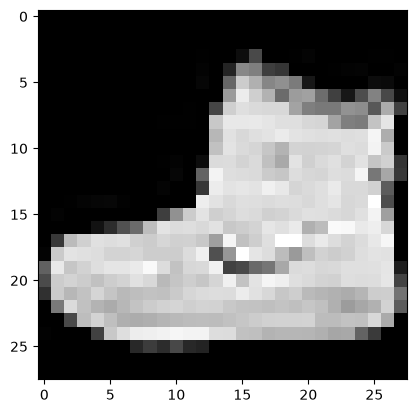

In [28]:
plt.imshow(image.squeeze(), cmap="gray")


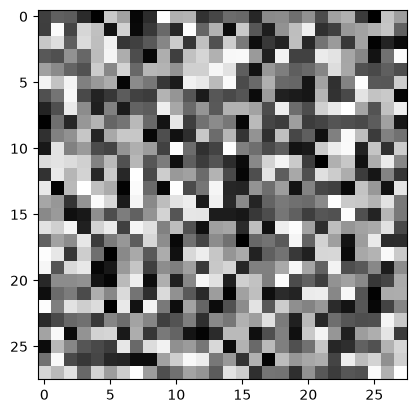

In [29]:
rand_image_tensor = torch.rand(size=(1, 28, 28))  # Random tensor with shape [channels, height, width]
rand_image = rand_image_tensor.squeeze()  # Remove the channel dimension for visualization
plt.imshow(rand_image, cmap="gray")

## Train and Evaluate the CNN (`model_2`)

Set up a fresh loss function and optimizer for `model_2`, then run the same `train_step()` / `test_step()` loop used for `model_1`, now on the convolutional architecture.

- `torch.optim.SGD(params=model_2.parameters(), lr=0.1)` — a new optimizer instance, since optimizers are bound to a specific model's parameters at creation
- `train_step(...)` / `test_step(...)` — the reusable functions defined earlier, now passed `model_2` and its dataloaders
- `device="cpu"` — passed explicitly here so training stays on CPU regardless of what `DEVICE` resolved to

**Note:** CNNs are more compute-intensive per batch than the linear baselines — expect this training loop to take noticeably longer than `model_0` or `model_1` even for the same number of epochs.


In [30]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.1)

In [31]:
torch.manual_seed(42)

# Measure time
from timeit import default_timer as timer
train_time_start_model_2 = timer()

# Train and test model 
epochs = 3
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(data_loader=train_dataloader, 
        model=model_2, 
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device="cpu"
    )
    test_step(data_loader=test_dataloader,
        model=model_2,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device="cpu"
    )

train_time_end_model_2 = timer()
total_train_time_model_2 = print_train_time(start=train_time_start_model_2,
                                           end=train_time_end_model_2,
                                           device="cpu")

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 0.59461 | Train accuracy: 78.49%


 33%|███▎      | 1/3 [00:08<00:16,  8.38s/it]

Test loss: 0.39822 | Test accuracy: 85.65%

Epoch: 1
---------
Train loss: 0.36021 | Train accuracy: 86.99%


 67%|██████▋   | 2/3 [00:16<00:08,  8.39s/it]

Test loss: 0.35426 | Test accuracy: 86.65%

Epoch: 2
---------
Train loss: 0.32348 | Train accuracy: 88.25%


100%|██████████| 3/3 [00:25<00:00,  8.41s/it]

Test loss: 0.32528 | Test accuracy: 88.08%


Train time on cpu: 25.231 seconds


## Evaluate All Models

Run `eval_model()` on each trained model (`model_0`, `model_1`, `model_2`) against the same test set so their results can be compared fairly.

- `eval_model(model=..., data_loader=test_dataloader, loss_fn=..., accuracy_fn=...)` — returns a dictionary with `model_name`, `model_loss`, and `model_acc`
- Same `test_dataloader` used for all three — keeping the evaluation set identical is what makes the comparison meaningful

**Note:** The `model_1` cell below re-creates a new `FashionMNISTModelV1` instance with `hidden_units=10` (untrained) rather than reusing the already-trained `model_1` from earlier — its results reflect this fresh, untrained model rather than the one trained via `train_step()`/`test_step()` above.


In [32]:
# Calculate model 0 results on test dataset
model_0_results = eval_model(model=model_0, data_loader=test_dataloader,
    loss_fn=loss_fn, accuracy_fn=accuracy_fn
)
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.4766390025615692,
 'model_acc': 83.42651757188499}

In [33]:


torch.manual_seed(42)
model_1 = FashionMNISTModelV1(input_shape=784, # number of input features
    hidden_units=10,
    output_shape=len(train_data.classes) # number of output classes desired
).to("cpu") # send model to GPU if it's available
next(model_1.parameters()).device # check model device

model_1_results = eval_model(model=model_1, 
    data_loader=test_dataloader,
    loss_fn=loss_fn, 
    accuracy_fn=accuracy_fn) 
model_1_results 

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 2.3021066188812256,
 'model_acc': 10.75279552715655}

In [34]:
# Get model_2 results 
model_2_results = eval_model(
    model=model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)
model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.3252837061882019,
 'model_acc': 88.07907348242811}

### Compare Models

Combine the three result dictionaries into a single `pandas.DataFrame` for a side-by-side view of loss, accuracy, and model name.

- `pd.DataFrame([model_0_results, model_1_results, model_2_results])` — each dict becomes one row, with keys becoming columns
- `.set_index("model_name")["model_acc"].plot(kind="barh")` — a horizontal bar chart comparing accuracy across models, easier to scan than raw numbers

**Note:** Comparing raw numbers alone can be misleading — check the earlier note about `model_1`'s results coming from an untrained instance before drawing conclusions from this comparison.


In [35]:

import pandas as pd
compare_results = pd.DataFrame([model_0_results, model_1_results, model_2_results])
compare_results

,model_name,model_loss,model_acc
0,FashionMNISTModelV0,0.476639,83.426518
1,FashionMNISTModelV1,2.302107,10.752796
2,FashionMNISTModelV2,0.325284,88.079073


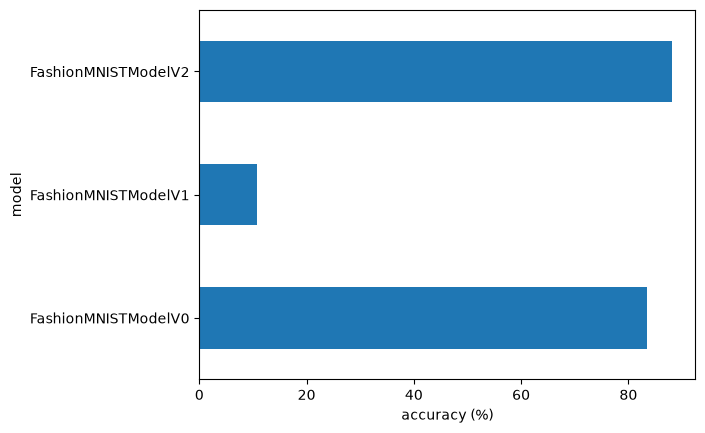

In [37]:
# Visualize our model results
compare_results.set_index("model_name")["model_acc"].plot(kind="barh")
plt.xlabel("accuracy (%)")
plt.ylabel("model");

### Make Predictions

Use the trained `model_2` (CNN) to predict on a random sample of test images, then visualize predictions against ground truth labels.

- `make_predictions(model, data, device)` — runs each sample through the model and converts raw logits to prediction probabilities via `torch.softmax()`
- `random.sample(list(test_data), k=9)` — pulls 9 random test images to keep the visualization small and readable
- `pred_classes = pred_probs.argmax(dim=1)` — converts probabilities to a single predicted class index per image
- Plot title color (green/red) — a quick visual cue for correct vs. incorrect predictions

**Note:** `make_predictions()` runs each sample through the model one at a time rather than batching them — fine for a demo of 9 images, but not the pattern to use for evaluating a full dataset (see `evaluate_model()`/`eval_model()` above for that).


In [39]:


def make_predictions(model: torch.nn.Module, data: list, device: torch.device = "cpu"):
    pred_probs = []
    model.eval()
    with torch.inference_mode():
        for sample in data:
            # Prepare sample
            sample = torch.unsqueeze(sample, dim=0).to(device) # Add an extra dimension and send sample to device

            # Forward pass (model outputs raw logit)
            pred_logit = model(sample)

            # Get prediction probability (logit -> prediction probability)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0) # note: perform softmax on the "logits" dimension, not "batch" dimension (in this case we have a batch size of 1, so can perform on dim=0)

            # Get pred_prob off GPU for further calculations
            pred_probs.append(pred_prob.cpu())
            
    # Stack the pred_probs to turn list into a tensor
    return torch.stack(pred_probs)



In [56]:
import random
random.seed(42)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

# View the first test sample shape and label
print(f"Test sample image shape: {test_samples[0].shape}\nTest sample label: {test_labels[0]} ({train_dataloader[test_labels[0]]})")

TypeError: 'DataLoader' object is not subscriptable

In [41]:
# Make predictions on test samples with model 2
pred_probs= make_predictions(model=model_2, 
                             data=test_samples)

# View first two prediction probabilities list
pred_probs[:2]

tensor([[9.9677e-08, 6.7383e-08, 7.2890e-08, 1.6626e-07, 1.5945e-08, 9.9984e-01,
         1.5033e-07, 9.2252e-06, 1.2918e-05, 1.3746e-04],
        [1.2498e-01, 3.7865e-01, 2.2182e-03, 1.1309e-01, 1.7144e-01, 4.4171e-05,
         2.0924e-01, 6.9567e-05, 1.2776e-04, 1.3164e-04]])

In [42]:
# Turn the prediction probabilities into prediction labels by taking the argmax()
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([5, 1, 7, 4, 3, 0, 4, 7, 1])

In [43]:
# Are our predictions in the same form as our test labels? 
test_labels, pred_classes

([5, 1, 7, 4, 3, 0, 4, 7, 1], tensor([5, 1, 7, 4, 3, 0, 4, 7, 1]))

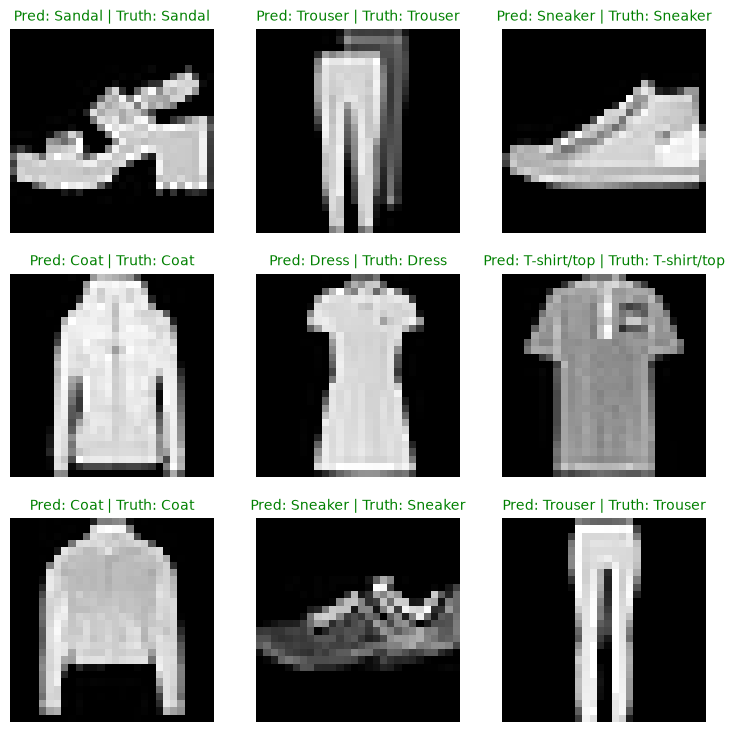

In [44]:
# Plot predictions
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
  # Create a subplot
  plt.subplot(nrows, ncols, i+1)

  # Plot the target image
  plt.imshow(sample.squeeze(), cmap="gray")

  # Find the prediction label (in text form, e.g. "Sandal")
  pred_label = train_data.classes[pred_classes[i]]

  # Get the truth label (in text form, e.g. "T-shirt")
  truth_label = train_data.classes[test_labels[i]]

  # Create the title text of the plot
  title_text = f"Pred: {pred_label} | Truth: {truth_label}"
  
  # Check for equality and change title colour accordingly
  if pred_label == truth_label:
      plt.title(title_text, fontsize=10, c="g") # green text if correct
  else:
      plt.title(title_text, fontsize=10, c="r") # red text if wrong
  plt.axis(False);

## Confusion Matrix

Visualize where `model_2` confuses one class for another by comparing all test predictions against true labels in a confusion matrix.

- `torchmetrics.ConfusionMatrix(num_classes=..., task='multiclass')` — computes the confusion matrix tensor from predictions vs. targets
- `mlxtend.plotting.plot_confusion_matrix(...)` — renders the matrix as a labeled heatmap using the dataset's class names
- The install-check cell above ensures `torchmetrics` and a recent `mlxtend` (`>=0.19.0`) are available before importing

**Note:** `y_pred_tensor` must be built first (previous cell) by running the full test set through `model_2` — the confusion matrix compares this complete set of predictions, not just the 9-sample demo above.


In [46]:
# Import tqdm for progress bar
from tqdm.auto import tqdm

# 1. Make predictions with trained model
y_preds = []
model_2.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Making predictions"):
    # Send data and targets to target device
    X, y = X.to("cpu"), y.to("cpu")
    # Do the forward pass
    y_logit = model_2(X)
    # Turn predictions from logits -> prediction probabilities -> predictions labels
    y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1) # note: perform softmax on the "logits" dimension, not "batch" dimension (in this case we have a batch size of 32, so can perform on dim=1)
    # Put predictions on CPU for evaluation
    y_preds.append(y_pred.cpu())
# Concatenate list of predictions into a tensor
y_pred_tensor = torch.cat(y_preds)

Making predictions: 100%|██████████| 313/313 [00:00<00:00, 417.81it/s]


In [48]:
# See if torchmetrics exists, if not, install it
try:
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")
    assert int(mlxtend.__version__.split(".")[1]) >= 19, "mlxtend verison should be 0.19.0 or higher"
except:
    !pip install -q torchmetrics -U mlxtend # <- Note: If you're using Google Colab, this may require restarting the runtime
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")

mlxtend version: 0.25.0


In [49]:
# Import mlxtend upgraded version
import mlxtend 
print(mlxtend.__version__)
assert int(mlxtend.__version__.split(".")[1]) >= 19 # should be version 0.19.0 or higher

0.25.0


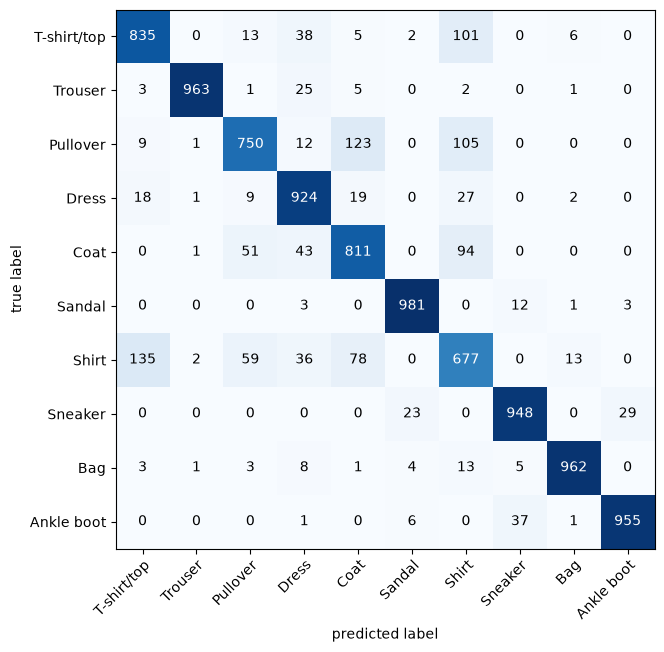

In [50]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# 2. Setup confusion matrix instance and compare predictions to targets
confmat = ConfusionMatrix(num_classes=len(test_data.classes), task='multiclass')
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=test_data.targets)

# 3. Plot the confusion matrix
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(), # matplotlib likes working with NumPy 
    class_names=test_data.classes, # turn the row and column labels into class names
    figsize=(10, 7)
);

### Save Best Model

Save `model_2`'s learned parameters to disk, then reload them into a fresh model instance to confirm the save/load round-trip works correctly.

- `torch.save(obj=model_2.state_dict(), f=MODEL_SAVE_PATH)` — saves only the learned weights/biases, not the full model object or architecture code
- `loaded_model_2.load_state_dict(torch.load(f=MODEL_SAVE_PATH))` — requires a `FashionMNISTModelV2` instance with matching `hidden_units` to load into
- `torch.isclose(..., atol=1e-08, rtol=0.0001)` — checks that the reloaded model's evaluation loss matches the original within a small tolerance, confirming nothing was lost in the save/load process

**Note:** Only `state_dict()` is saved here — reloading requires the `FashionMNISTModelV2` class definition to already exist in the environment, since the architecture itself isn't stored in the `.pth` file.


In [51]:
from pathlib import Path

# Create models directory (if it doesn't already exist), see: https://docs.python.org/3/library/pathlib.html#pathlib.Path.mkdir
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, # create parent directories if needed
                 exist_ok=True # if models directory already exists, don't error
)

# Create model save path
MODEL_NAME = "03_pytorch_computer_vision_model_2.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_2.state_dict(), # only saving the state_dict() only saves the learned parameters
           f=MODEL_SAVE_PATH)

Saving model to: models\03_pytorch_computer_vision_model_2.pth


In [52]:
# Create a new instance of FashionMNISTModelV2 (the same class as our saved state_dict())
# Note: loading model will error if the shapes here aren't the same as the saved version
loaded_model_2 = FashionMNISTModelV2(input_shape=1, 
                                    hidden_units=10, # try changing this to 128 and seeing what happens 
                                    output_shape=10) 

# Load in the saved state_dict()
loaded_model_2.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

# Send model to GPU
loaded_model_2 = loaded_model_2.to("cpu")

In [53]:
# Evaluate loaded model
torch.manual_seed(42)

loaded_model_2_results = eval_model(
    model=loaded_model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn, 
    accuracy_fn=accuracy_fn
)

loaded_model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.3252837061882019,
 'model_acc': 88.07907348242811}

In [54]:
model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.3252837061882019,
 'model_acc': 88.07907348242811}

In [55]:
# Check to see if results are close to each other (if they are very far away, there may be an error)
torch.isclose(torch.tensor(model_2_results["model_loss"]), 
              torch.tensor(loaded_model_2_results["model_loss"]),
              atol=1e-08, # absolute tolerance
              rtol=0.0001) # relative tolerance

tensor(True)